In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/titanic.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df.shape

(891, 12)

## Box Plot – Detect Outliers (Age)

<Axes: ylabel='Age'>

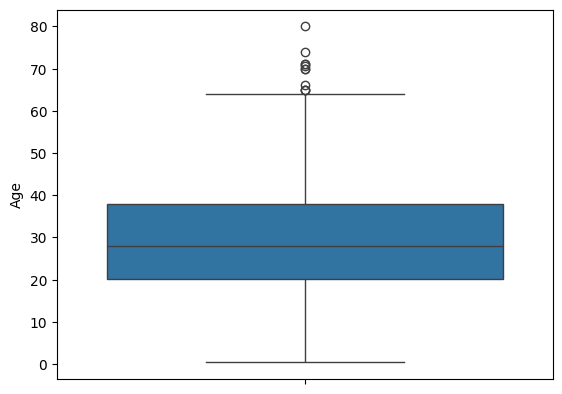

In [6]:
sns.boxplot(df['Age'])

## Fill missing values

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Dropped 'Cabin' since most values are missing





In [9]:
df.drop(columns=["Cabin"], inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Correlation Between Features - Heatmap




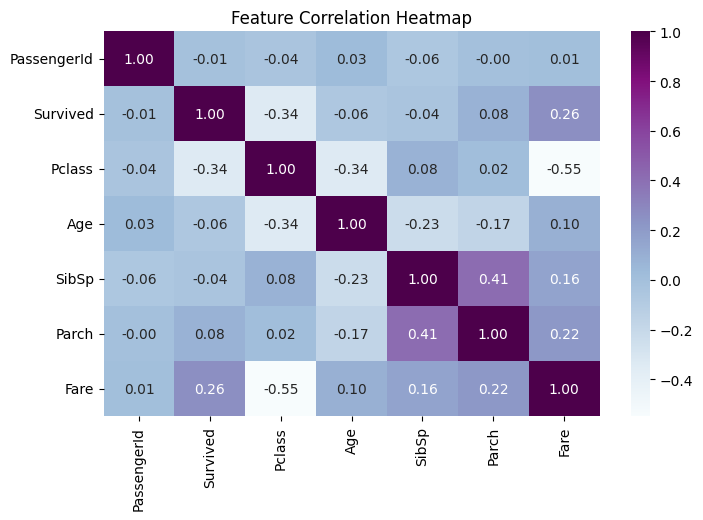

In [10]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="BuPu", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## Survival Status - Countplot

<ipython-input-11-057adc3d7a3b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=df, palette="coolwarm")


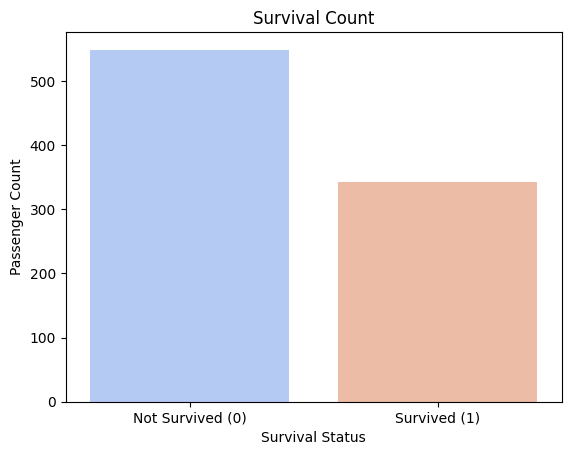

In [11]:
# Count of survivors(1) vs non-survivors(0)
sns.countplot(x="Survived", data=df, palette="coolwarm")
plt.title("Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Count")
plt.xticks([0, 1], ["Not Survived (0)", "Survived (1)"])
plt.show()


## Survival Count by Gender - Countplot





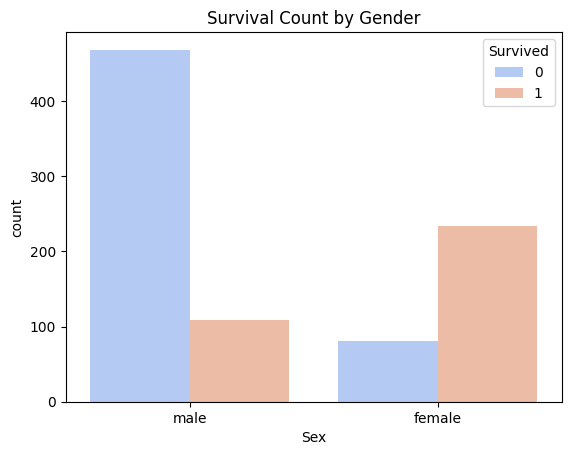

In [12]:
# Survival count by gender
sns.countplot(x="Sex", hue="Survived", data=df, palette="coolwarm")
plt.title("Survival Count by Gender")
plt.show()

## Survival Count by Passenger Class - Countplot

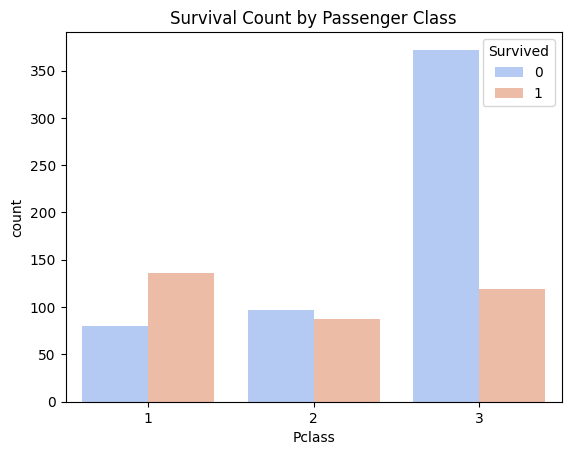

In [13]:
# Survival count by passenger class
sns.countplot(x="Pclass", hue="Survived", data=df, palette="coolwarm")
plt.title("Survival Count by Passenger Class")
plt.show()

Age Distribution - Histogram

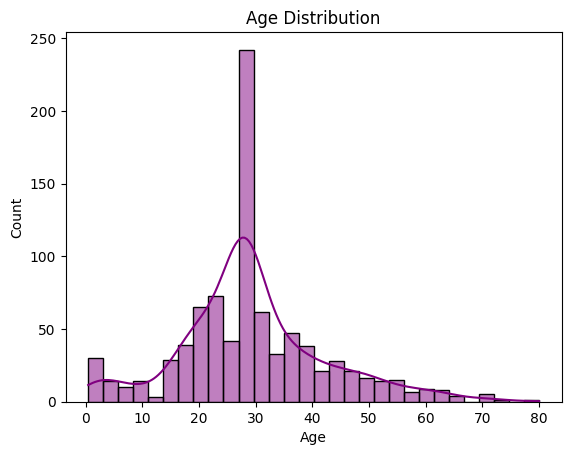

In [14]:
# Age distribution
sns.histplot(df["Age"], bins=30, kde=True, color="purple")
plt.title("Age Distribution")
plt.show()

## Survival Rate by Gender - Pie Chart

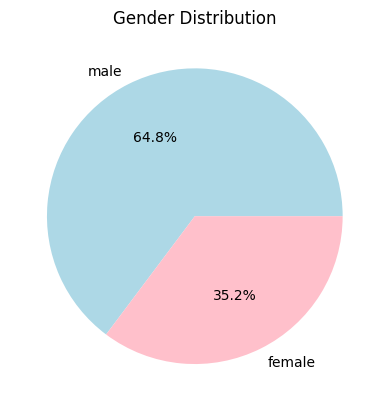

In [15]:
df["Sex"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["lightblue", "pink"])
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

## Relationship Between Multiple Numeric Variables - Pairplot

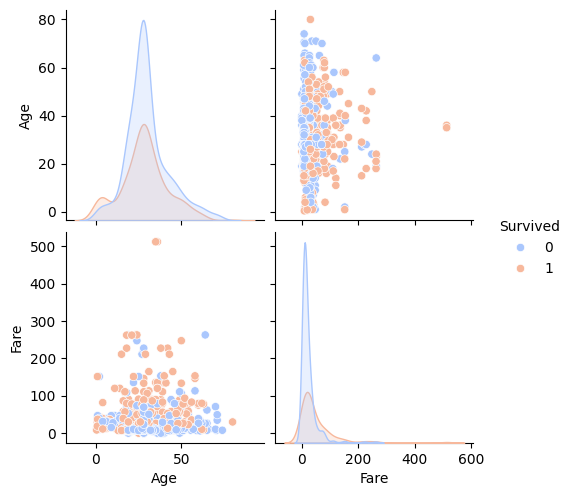

In [16]:
sns.pairplot(df[["Age", "Fare", "Survived"]], hue="Survived", palette="coolwarm")
plt.show()